In [36]:
import polars as pl
import matplotlib.pyplot as plt

## Load Data

In [37]:
# Read World Bank market capitalization data (in current USD)
market_cap_raw = pl.read_csv("./Source/API_CM.MKT.LCAP.CD_DS2_en_csv_v2_1108.csv", skip_rows=4)

## Process and Calculate Weights

In [45]:
# Define the JST countries we want in the final dataset
JST_countries = [
    "AUS", "BEL", "CAN", "DNK", "FIN", "FRA", "DEU", "IRL", "ITA",
    "JPN", "NLD", "NOR", "PRT", "ESP", "SWE", "CHE", "GBR", "USA",
]

# Unpivot data to long format and filter for JST countries only
market_cap_data = (
    market_cap_raw.drop("Indicator Name", "Indicator Code", "Country Name")
    .unpivot(index="Country Code", variable_name="Year", value_name="Market Cap")
    .filter(pl.col("Country Code").is_in(JST_countries))
    .with_columns(
        pl.col("Year").cast(pl.Int64, strict=False),
        pl.col("Market Cap").cast(pl.Float64, strict=False).fill_null(0),
    )
)

# Calculate total market cap for each year
total_market_cap_by_year = (
    market_cap_data
    .group_by("Year")
    .agg(pl.col("Market Cap").sum().alias("Total Market Cap"))
    .sort("Year")
)

# Calculate market cap weights (percentage of total)
market_cap_weights = (
    market_cap_data.join(total_market_cap_by_year, on="Year", how="inner")
    .select(
        "Country Code", 
        "Year", 
        (pl.col("Market Cap") / pl.col("Total Market Cap")).alias("Weight")
    )
)

# Apply minimum weight floor of 2% and re-normalize to sum to 1.0
market_cap_weights_final = (
    market_cap_weights
    .with_columns(pl.max_horizontal("Weight", pl.lit(0.02)).alias("Weight"))
    .with_columns(pl.col("Weight") / pl.col("Weight").sum().over("Year"))
    .drop_nans()
)


In [46]:
market_cap_weights_final

Country Code,Year,Weight
str,i64,f64
"""AUS""",1975,0.016874
"""BEL""",1975,0.016874
"""CAN""",1975,0.016874
"""CHE""",1975,0.016874
"""DEU""",1975,0.038992
…,…,…
"""NLD""",2025,0.016319
"""NOR""",2025,0.016319
"""PRT""",2025,0.016319


## Visualize Market Cap Weights

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_54212\3703050465.py:6: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="Year", columns="Country Code", values="Weight")


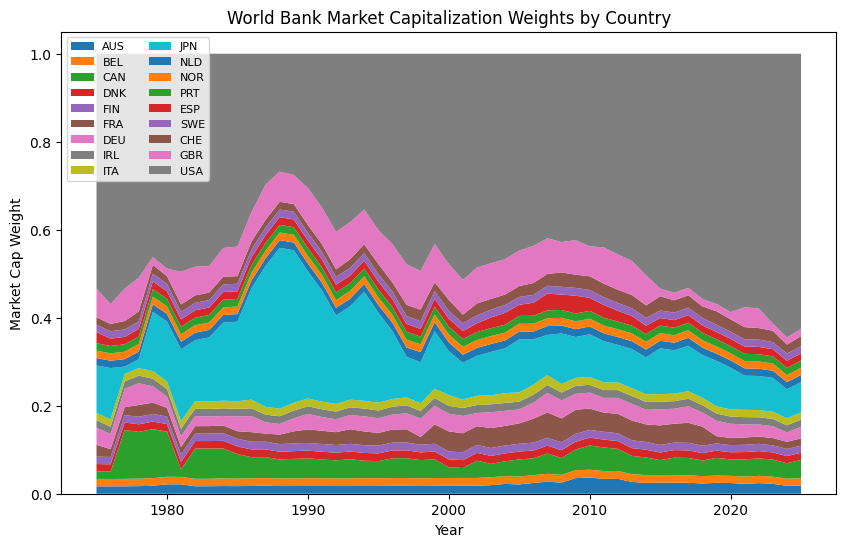

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

# Pivot to wide format for stacked area plot
pivoted = (
    market_cap_weights_final
    .pivot(index="Year", columns="Country Code", values="Weight")
    .sort("Year")
    .fill_null(0)
)

# Create stacked area plot
ax.stackplot(
    pivoted["Year"], 
    [pivoted[country] for country in JST_countries], 
    labels=JST_countries
)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.set_xlabel("Year")
ax.set_ylabel("Market Cap Weight")
ax.set_title("World Bank Market Capitalization Weights by Country")
plt.show()

## Quality Checks

In [48]:
print("=== Data Quality Checks ===\n")

# Check 1: Verify weights sum to approximately 1.0 for each year
yearly_sums = (
    market_cap_weights_final
    .group_by("Year")
    .agg(pl.col("Weight").sum().alias("Total"))
)

print("1. Yearly weight sums:")
print(f"   Min sum: {yearly_sums['Total'].min():.6f}")
print(f"   Max sum: {yearly_sums['Total'].max():.6f}")
print(f"   Mean sum: {yearly_sums['Total'].mean():.6f}")

# Check if any year deviates significantly from 1.0
problematic_years = yearly_sums.filter((pl.col("Total") < 0.999) | (pl.col("Total") > 1.001))
if len(problematic_years) > 0:
    print(f"   WARNING: {len(problematic_years)} years with totals outside [0.999, 1.001]")
    print(problematic_years)
else:
    print("   [OK] All years sum to 1.0")

# Check 2: Verify minimum weight floor applied correctly
min_weight = market_cap_weights_final["Weight"].min()
print(f"\n2. Minimum weight: {min_weight:.6f}")
if min_weight >= 0.02 - 1e-6:  # Allow small floating point error
    print("   [OK] 2% minimum weight floor applied")
else:
    print(f"   WARNING: Found weights below 2% floor!")

# Check 3: Verify no negative values
negative_count = market_cap_weights_final.filter(pl.col("Weight") < 0).height
print(f"\n3. Negative values: {negative_count}")
if negative_count > 0:
    print("   WARNING: Found negative weights!")
else:
    print("   [OK] No negative values")

# Check 4: Verify year coverage
year_range = market_cap_weights_final["Year"].unique().sort()
print(f"\n4. Year coverage: {year_range.min()} to {year_range.max()} ({len(year_range)} years)")

# Check 5: Verify all countries present
countries_present = market_cap_weights_final["Country Code"].unique().sort()
print(f"\n5. Countries present: {len(countries_present)}")
print(f"   Expected: {len(JST_countries)}")
if len(countries_present) == len(JST_countries):
    print("   [OK] All countries present")
else:
    missing = set(JST_countries) - set(countries_present.to_list())
    print(f"   WARNING: Missing countries: {missing}")

# Check 6: Summary statistics
print(f"\n6. Summary statistics:")
print(market_cap_weights_final.group_by("Country Code").agg([
    pl.col("Weight").mean().alias("Mean"),
    pl.col("Weight").min().alias("Min"),
    pl.col("Weight").max().alias("Max"),
]).sort("Mean", descending=True))

=== Data Quality Checks ===

1. Yearly weight sums:
   Min sum: 1.000000
   Max sum: 1.000000
   Mean sum: 1.000000
   [OK] All years sum to 1.0

2. Minimum weight: 0.016255

3. Negative values: 0
   [OK] No negative values

4. Year coverage: 1975 to 2025 (51 years)

5. Countries present: 18
   Expected: 18
   [OK] All countries present

6. Summary statistics:
shape: (18, 4)
┌──────────────┬──────────┬──────────┬──────────┐
│ Country Code ┆ Mean     ┆ Min      ┆ Max      │
│ ---          ┆ ---      ┆ ---      ┆ ---      │
│ str          ┆ f64      ┆ f64      ┆ f64      │
╞══════════════╪══════════╪══════════╪══════════╡
│ USA          ┆ 0.469058 ┆ 0.268026 ┆ 0.644851 │
│ JPN          ┆ 0.135559 ┆ 0.016881 ┆ 0.365317 │
│ GBR          ┆ 0.062102 ┆ 0.016255 ┆ 0.091923 │
│ CAN          ┆ 0.046462 ┆ 0.016711 ┆ 0.111273 │
│ DEU          ┆ 0.033416 ┆ 0.021198 ┆ 0.049451 │
│ …            ┆ …        ┆ …        ┆ …        │
│ BEL          ┆ 0.017345 ┆ 0.016255 ┆ 0.018008 │
│ NOR          ┆ 0.017

In [50]:
# Write the final market cap weights to CSV
market_cap_weights_final.rename({"Country Code": "Country", "Weight": "Percentage"}).write_csv("./Processed/world_bank_market_cap_weights.csv")
print("[OK] Data written to ./Processed/world_bank_market_cap_weights.csv")

[OK] Data written to ./Processed/world_bank_market_cap_weights.csv
